Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

1. [0-1 pkt] Zaproponuj EDA po skalowaniu cech (tj. analiza macierzy zliczeń)
1. [0-2 pkt] Dostosuj parametry wektoryzacji (np. `ngram_range`, `min_df`, `max_df`) na podstawie analizy wyżej. Zrób wyszukiwanie po parametrach, używając `ROCAUC` jako miary (zob. [roc_auc_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html))
1. [0-1 pkt] Porównanj wyniki z rozkładem Bernoulliego. Zidentyfikuj przykłady, dla których każdy z modeli działa lepiej
1. [0-1.5 pkt] Użyj transformacji [TF-IDF](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html) zaraz po wektoryzacji dla rozkładu wielomianowego i Gaussowskiego. W tym celu użyj funkcjonalności `Pipeline`
   1. w przypadku rozkładu Gaussowskiego wymagane będzie użycia transformatora postaci gęstej macierzy (patrz kod niżej)
   1. Skomentuj, dlaczego model z rozkładem Gaussa działa gorzej
1. [0-1.5 pkt] Wytrenuj [regresję logistyczną](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), robiąc przeszukanie po hiperparametrach  
1. [0-1 pkt] Porównaj krzywe kalibracyjne (użyj tego [API](https://scikit-learn.org/stable/modules/calibration.html)) dla obu modeli. Skomentuj wyniki
1. [0-2 pkt] Spróbuj znaleźć dwa reprezentatywne n-gramy, które najlepiej separują klasy. Wyrysuj obszary decyzyjne dla obu klasyfikatorów

```Python
from sklearn.base import TransformerMixin, BaseEstimator

class DenseTransformer(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        return X.toarray()
```

# Zadanie dodatkowe [0-4] pkt

1. [0-3 pkt] Zaimplementuj [elastyczny naiwny klasyfikator Bayesa](https://arxiv.org/pdf/1302.4964) tj. NBC, w którym wiaygodność $p(x_i | y_k)$ jest modelowana osobno dla każdej klasy $k$ na podstawie [KDE](https://en.wikipedia.org/wiki/Kernel_density_estimation) dla wszystkich punktów treningowych ($i=1\dots n$)
2. [0-1 pkt] Porównaj wyniki uzyskane za pomocą Gaussowskiego KDE dla różnych wartości parametru wygładzania ($h$, *smoothing*, *bandwidth*) z "globalnym" klasyfikatorem z rozkładem Gaussa (patrz zadanie obowiązkowe)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

sklearn.set_config(transform_output="pandas")

#### załadowanie danych

In [4]:
sms = pd.read_csv('SMSSpamCollection',
                  delimiter='\t', header=None, names=['is_spam', 'text'])

In [5]:
sms.head(5)

,is_spam,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#### preprocessing danych

In [6]:
sms.loc[sms['is_spam'] == 'spam', 'is_spam'] = 1
sms.loc[sms['is_spam'] == 'ham', 'is_spam']  = 0
sms['is_spam'] = sms['is_spam'].astype('int8')


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

X = sms['text']
y = sms['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X,y,stratify=y,test_size=0.2,random_state =0)

vect = CountVectorizer(stop_words='english')
X_train_scaled = vect.fit_transform(X_train)
X_test_scaled = vect.transform(X_test)

### Wstępna analiza macierzy zliczeń



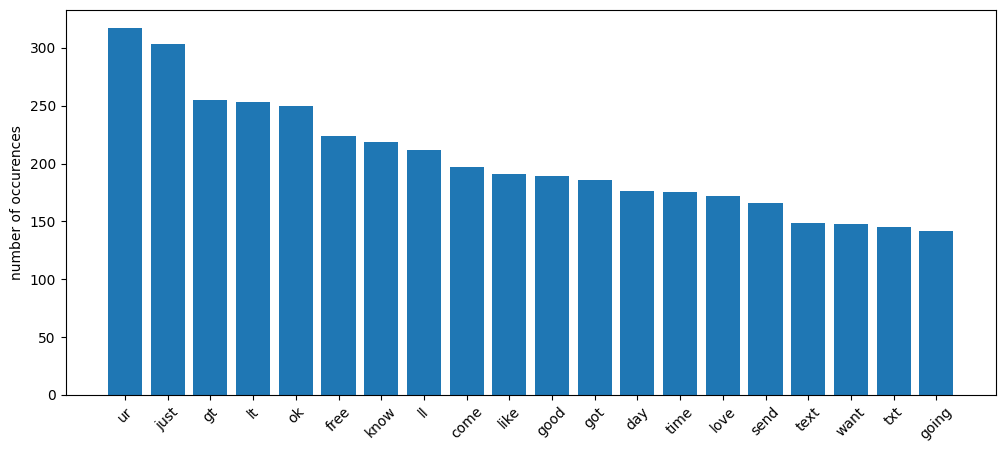

In [8]:
word_counts = np.array(X_train_scaled.sum(axis=0)).flatten()
words = vect.get_feature_names_out()

df_words = pd.DataFrame({'word': words, 'count': word_counts})
df_words = df_words.sort_values(by='count',ascending=False)

plt.figure(figsize=(12,5))
plt.bar(df_words['word'].head(20),df_words['count'].head(20))
plt.ylabel('number of occurences')
plt.xticks(rotation=45)
plt.show()

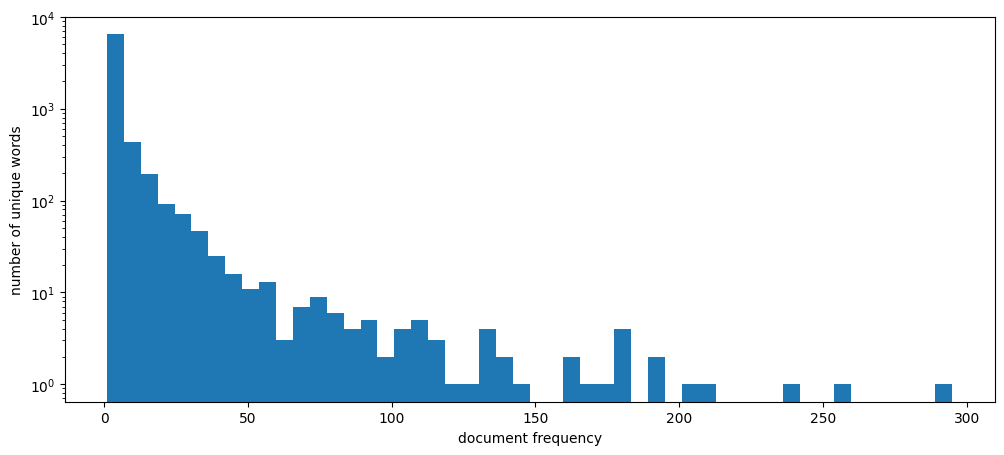

In [9]:
doc_frequencies = np.array((X_train_scaled > 0).sum(axis=0)).flatten()
plt.figure(figsize=(12,5))
plt.hist(doc_frequencies,bins=50,log=True)
plt.xlabel('document frequency')
plt.ylabel('number of unique words')
plt.show()

In [10]:
single_doc_words = np.sum(doc_frequencies == 1)
print(f'Liczba słów występujących tylko w jednej wiadomości: {single_doc_words}')
print(f'Procent słów występujących tylko w jednej wiadomości: {single_doc_words/len(words)*100:.2f}%')

Liczba słów występujących tylko w jednej wiadomości: 4072
Procent słów występujących tylko w jednej wiadomości: 54.72%


Na wykresie przedstawiającym najpopularniejsze tokeny w zbiorze widać słowa mogące wskazywać na zawartość spamu (np. free), a także pozostałości po formatowaniu HTML, które możnaby wyczyścić (gt, lt)
Na drugim wykresie widać, że znaczna część słów (ponad połowa) występuje w tylko jednej wiadomości.

### Dostosowanie parametrów wektoryzacji

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

pipeline = Pipeline([
    ('vect', CountVectorizer(stop_words='english')),
    ('nb', MultinomialNB())
])

param_grid = {
    'vect__min_df': [2,3,4,5],
    'vect__max_df': [0.5,0.75,1.0],
    'vect__ngram_range': [(1,1),(1,2),(1,3)]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc',n_jobs=-1)

grid.fit(X_train, y_train)

print(f"Najlepsze parametry: {grid.best_params_}")
print(f"Najlepszy wynik roc auc (dla treningowego cross validation): {grid.best_score_}")


Najlepsze parametry: {'vect__max_df': 0.5, 'vect__min_df': 4, 'vect__ngram_range': (1, 1)}
Najlepszy wynik roc auc (dla treningowego cross validation): 0.9890211661585125


In [12]:
from sklearn.metrics import roc_auc_score

y_test_proba = grid.predict_proba(X_test)[:, 1]
final_roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"roc auc na zbiorze testowym: {final_roc_auc:.4f}")

roc auc na zbiorze testowym: 0.9764


komentarz do wyników:

Najlepsze wyniki dało odrzucenie słów występujących w mniej niż 4 wiadomościach oraz takich, które występują w ponad 50% wiadomości.

Skuteczniejesze okazało się także używanie pojedynczych słów, zamiast uwzględnienia par bądź trójek kolejnych słów

Wyniki modelu na zbiorze treningowym podczas cross validation były bardzo wysokie (0.989), co mogło być sygnałem overfittingu, natomiast po przetestowaniu modelu na zbiorze testowym, model również uzyskał bardzo dobry wynik na poziomie 0.976. Oznacza to, że uniknęliśmy overfittingu i uzyskaliśmy model który dobrze radzi sobie z wykrywaniem spamu.

### Porównanie wyników z rozkladem Bernoulliego

In [13]:
from sklearn.naive_bayes import BernoulliNB

pipe_multi = Pipeline([
    ('vect', CountVectorizer(stop_words='english', min_df=4, max_df=0.5, ngram_range=(1, 1))),
    ('nb', MultinomialNB())
])


pipe_bern = Pipeline([
    ('vect', CountVectorizer(stop_words='english', min_df=4, max_df=0.5, ngram_range=(1, 1))),
    ('nb', BernoulliNB())
])

pipe_multi.fit(X_train, y_train)
pipe_bern.fit(X_train, y_train)

roc_multi = roc_auc_score(y_test, pipe_multi.predict_proba(X_test)[:, 1])
roc_bern = roc_auc_score(y_test, pipe_bern.predict_proba(X_test)[:, 1])

print(f"roc auc (rozkłąd wielomianowy): {roc_multi:.4f}")
print(f"roc auc (rozkład bernoulliego): {roc_bern:.4f}")

roc auc (rozkłąd wielomianowy): 0.9764
roc auc (rozkład bernoulliego): 0.9895


In [14]:
y_pred_multi = pipe_multi.predict(X_test)
y_pred_bern = pipe_bern.predict(X_test)

results_df = pd.DataFrame({
    'text': X_test,
    'true_label': y_test,
    'pred_multi': y_pred_multi,
    'pred_bern': y_pred_bern
})

multi_better = results_df[(results_df['true_label'] == results_df['pred_multi']) &
                          (results_df['true_label'] != results_df['pred_bern'])]

bern_better = results_df[(results_df['true_label'] == results_df['pred_bern']) &
                         (results_df['true_label'] != results_df['pred_multi'])]

print("przykłady w których model z rozkładem wielomianowym radzi sobie lepiej")
if not multi_better.empty:
    example_m = multi_better.iloc[0]
    print(f"Prawdziwa klasa: {example_m['true_label']} | Multi: {example_m['pred_multi']} | Bern: {example_m['pred_bern']}")
    print(f"Treść: {example_m['text']}\n")
else:
    print("Brak takich przykładów w zbiorze testowym.\n")

print("przykłady w których model z rozkładem bernoulliego radzi sobie lepiej")
if not bern_better.empty:
    example_b = bern_better.iloc[0]
    print(f"Prawdziwa klasa: {example_b['true_label']} | Multi: {example_b['pred_multi']} | Bern: {example_b['pred_bern']}")
    print(f"Treść: {example_b['text']}")
else:
    print("Brak takich przykładów w zbiorze testowym.")

przykłady w których model z rozkładem wielomianowym radzi sobie lepiej
Prawdziwa klasa: 1 | Multi: 1 | Bern: 0
Treść: Please CALL 08712402972 immediately as there is an urgent message waiting for you

przykłady w których model z rozkładem bernoulliego radzi sobie lepiej
Prawdziwa klasa: 0 | Multi: 1 | Bern: 0
Treść: Total video converter free download type this in google search:)


Rozkład Bernoulliego osiągnął wyższy wynik ogólny w metryce roc auc - 0.9895, co sugeruje, że w przypadku tych wiadomości sam fakt wystąpienia danego słowa często jest lepszym wyznacznikiem niż liczba jego powtórzeń. Z analizy przykładów wynika jednak, że model wielomianowy jest czulszy na typowo spamowe słowa-klucze (np. "CALL", "urgent"), podczas gdy Bernoulli trafniej unika fałszywych alarmów, gdy w zwykłej wiadomości pojawi się pojedyncze słowo mogące sygnalizować spam (np. "free").

### Transformacja td-idf dla rozkładu wielomianowego i gaussowskiego

In [16]:
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.feature_extraction.text import TfidfTransformer

class DenseTransformer(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        return X.toarray()

In [17]:
from sklearn.naive_bayes import GaussianNB

pipe_tfidf_multi = Pipeline([
    ('vect', CountVectorizer(stop_words='english', min_df=4, max_df=0.5, ngram_range=(1, 1))),
    ('tfidf', TfidfTransformer()),
    ('nb', MultinomialNB())
])

pipe_tfidf_gauss = Pipeline([
    ('vect', CountVectorizer(stop_words='english', min_df=4, max_df=0.5, ngram_range=(1, 1))),
    ('tfidf', TfidfTransformer()),
    ('dense', DenseTransformer()),
    ('nb', GaussianNB())
])

pipe_tfidf_multi.fit(X_train, y_train)
pipe_tfidf_gauss.fit(X_train, y_train)

roc_tfidf_multi = roc_auc_score(y_test, pipe_tfidf_multi.predict_proba(X_test)[:, 1])
roc_tfidf_gauss = roc_auc_score(y_test, pipe_tfidf_gauss.predict_proba(X_test)[:, 1])

print(f"roc auc (TF-IDF + wielomianowy): {roc_tfidf_multi:.4f}")
print(f"roc auc (TF-IDF + gaussowski):   {roc_tfidf_gauss:.4f}")

roc auc (TF-IDF + wielomianowy): 0.9836
roc auc (TF-IDF + gaussowski):   0.8474


model z rozkładem wielomianowym z wykorzystaniem transformacji TF-IDF radzi sobie lepiej niż bez tej transformacji, natomiast nieznacznie gorzej niż przy wykorzystaniu rozkladu Bernoulliego.

model wykorzystujący rozkład gaussowski radzi sobie diametralnie gorzej. Wynika to z faktu niedopasowania opracowywanych danych do założeń matematycznych tego modelu. Model gaussowski zakłada rozkład normalny cech, natomiast dla danych tekstowych, nawet po wykorzystaniu TF-IDF, rozkład jest skośny i rzadki (większość słów nie występuje w pojedynczej wiadomości).
Wynika to z niedopasowania założeń matematycznych modelu do natury danych tekstowych.

Z kolei rozkład wielomianowy dobrze radzi sobie z modelowaniem częstotliwości wystąpień słów i lepiej radzi sobie ze znaczną liczbą wyzerowanych cech.

#### Regresja logistyczna

In [19]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('vect', CountVectorizer(stop_words='english', min_df=4, max_df=0.5, ngram_range=(1, 1))),
    ('tfidf', TfidfTransformer()),
    ('lr', LogisticRegression(solver='liblinear', random_state=0))
])

param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2']
}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train, y_train)

print(f"Najlepsze parametry: {grid_lr.best_params_}")
print(f"Najlepszy wynik roc auc podczas walidacji w cv: {grid_lr.best_score_:.4f}")

y_test_proba_lr = grid_lr.predict_proba(X_test)[:, 1]
print(f"roc auc na zbiorze testowym: {roc_auc_score(y_test, y_test_proba_lr):.4f}")

Najlepsze parametry: {'lr__C': 10, 'lr__penalty': 'l2'}
Najlepszy wynik roc auc podczas walidacji w cv: 0.9923
roc auc na zbiorze testowym: 0.9830


Regresja logistyczna osiągnęła dobry wynik na zbiorze testowym, porównywalny do modelu bayesowskiego z wykorzstaniem rozkładu wielomianowego, oraz nieznacznie gorszym od klasyfikatora wykorzystującego rozkład bernoulliego.





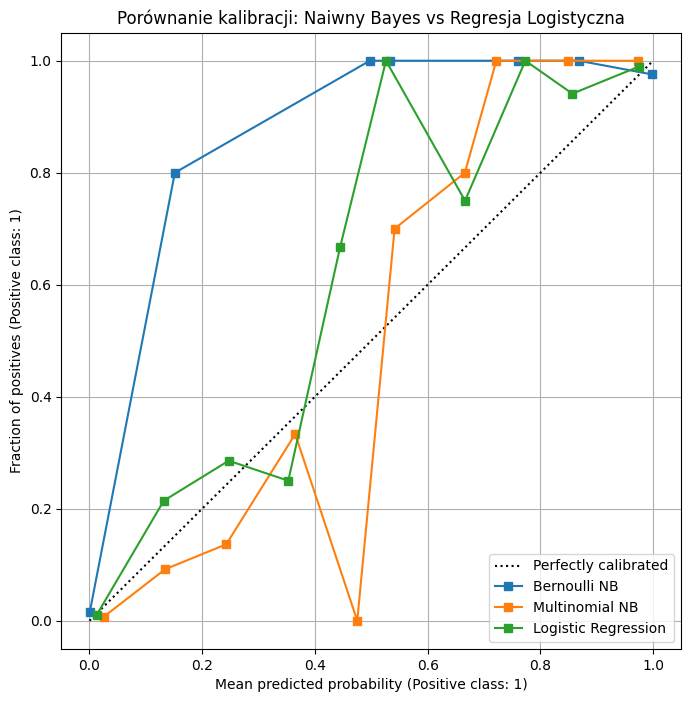

In [21]:
from sklearn.calibration import CalibrationDisplay

models = [
    (pipe_bern, "Bernoulli NB"),
    (pipe_tfidf_multi, "Multinomial NB"),
    (grid_lr.best_estimator_, "Logistic Regression")
]

fig, ax = plt.subplots(figsize=(8, 8))

for model, name in models:
    CalibrationDisplay.from_estimator(
        model, X_test, y_test, n_bins=10, name=name, ax=ax
    )

ax.set_title("Porównanie kalibracji: Naiwny Bayes vs Regresja Logistyczna")
ax.grid(True)
plt.show()

Regresja logistyczna jest najbliżej prostej oznaczonej jako perfekcyjna kalibracja. Jest to spodziewane, ponieważ jako model deskryptywny optymalizuje wiarygodność przewidywanych prawdopodobieństw przy pomocy binarnej entropii krzyżowej.

Multinomial NB z wykorzstaniem transformacji TF-IDF wykazyje dużą niestabilność i miejscami mocno odbiega od prostej kalibracji.

Bernoulli NB mimo najwyższego wyniku roc auc, ma najbardziej odbiegającą krzywą kalibracji i wykazuje duży overconfidence bardzo szybko osiągając wysokie wyniki.
